Pneumonia is one of the leading respiratory illnesses worldwide, and its timely and accurate diagnosis is essential for effective treatment. Manually reviewing chest X-rays is a critical step in this process, and AI can provide valuable support by helping to expedite the assessment. In your role as a consultant data scientist, you will test the ability of a deep learning model to distinguish pneumonia cases from normal images of lungs in chest X-rays.

By fine-tuning a pre-trained convolutional neural network, specifically the ResNet-18 model, your task is to classify X-ray images into two categories: normal lungs and those affected by pneumonia. You can leverage its already trained weights and get an accurate classifier trained faster and with fewer resources.

## The Data

<img src="x-rays_sample.png" align="center"/>
&nbsp

You have a dataset of chest X-rays that have been preprocessed for use with a ResNet-18 model. You can see a sample of 5 images from each category above. Upon unzipping the `chestxrays.zip` file (code provided below), you will find your dataset inside the `data/chestxrays` folder divided into `test` and `train` folders. 

There are 150 training images and 50 testing images for each category, NORMAL and PNEUMONIA (300 and 100 in total). For your convenience, this data has already been loaded into a `train_loader` and a `test_loader` using the `DataLoader` class from the PyTorch library. 

In [1]:
import random
import numpy as np
from torchvision.transforms import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import torch
from torchvision import models
import torch.nn as nn
import torch.optim as optim

from torchmetrics import Accuracy, F1Score

torch.manual_seed(101010)
np.random.seed(101010)
random.seed(101010)

In [2]:
import os
import zipfile

# Unzip the data folder
if not os.path.exists('data/chestxrays'):
    with zipfile.ZipFile('data/chestxrays.zip', 'r') as zip_ref:
        zip_ref.extractall('data')

In [3]:
# Define the transformations to apply to the images for use with ResNet-18
transform_mean = [0.485, 0.456, 0.406]
transform_std =[0.229, 0.224, 0.225]
transform = transforms.Compose([transforms.ToTensor(), 
                                transforms.Normalize(mean=transform_mean, std=transform_std)])

# Apply the image transforms
train_dataset = ImageFolder('data/chestxrays/train', transform=transform)
test_dataset = ImageFolder('data/chestxrays/test', transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=len(train_dataset) // 2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

In [4]:
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/shankar/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|███████████████████████████████████████| 44.7M/44.7M [00:47<00:00, 993kB/s]


In [5]:
# Freeze the parameters of the model
for param in resnet18.parameters():
    param.requires_grad = False

# Modify the final layer for binary classification
resnet18.fc = nn.Linear(resnet18.fc.in_features, 1)

In [6]:
def train(model, train_loader, criterion, optimizer, num_epochs):
    
    for epoch in range(num_epochs):
        model.train()

        running_loss = 0.0
        running_accuracy = 0

        # Iterate over the batches of the train loader
        for inputs, labels in train_loader:

            optimizer.zero_grad()
            
            labels = labels.float().unsqueeze(1)

            outputs = model(inputs)
            preds = torch.sigmoid(outputs) > 0.5 # Binary classification
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_accuracy += torch.sum(preds == labels.data)

        # Calculate the train loss and accuracy for the current epoch
        train_loss = running_loss / len(train_dataset)
        train_acc = running_accuracy.double() / len(train_dataset)

        # Print the epoch results
        print('Epoch [{}/{}], train loss: {:.4f}, train acc: {:.4f}'
              .format(epoch+1, num_epochs, train_loss, train_acc))


In [7]:
# Set the model to ResNet-18
model = resnet18

# Fine-tune the ResNet-18 model for 3 epochs using the train_loader
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.01)
criterion = torch.nn.BCEWithLogitsLoss()
train(model, train_loader, criterion, optimizer, num_epochs=3)

Epoch [1/3], train loss: 1.3915, train acc: 0.4567
Epoch [2/3], train loss: 0.8973, train acc: 0.4633
Epoch [3/3], train loss: 0.9199, train acc: 0.5033


In [8]:
model = resnet18
model.eval()

# Initialize metrics for accuracy and F1 score
accuracy_metric = Accuracy(task="binary")
f1_metric = F1Score(task="binary")

# Create lists store all predictions and labels
all_preds = []
all_labels = []

# Disable gradient calculation for evaluation
with torch.no_grad():
  for inputs, labels in test_loader:
    # Forward pass
    outputs = model(inputs)
    preds = torch.sigmoid(outputs).round()  # Round to 0 or 1

    # Extend the lists with predictions and labels
    all_preds.extend(preds.tolist())
    all_labels.extend(labels.unsqueeze(1).tolist())

    # Convert lists back to tensors
    all_preds = torch.tensor(all_preds)
    all_labels = torch.tensor(all_labels)

    # Calculate accuracy and F1 score
    test_accuracy = accuracy_metric(all_preds, all_labels).item()
    test_f1_score = f1_metric(all_preds, all_labels).item()

In [9]:
print(f"\nTest accuracy: {test_accuracy:.3f}\nTest F1-score: {test_f1_score:.3f}")


Test accuracy: 0.580
Test F1-score: 0.704


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


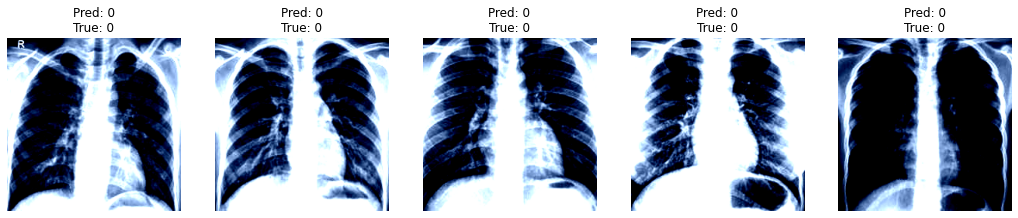

In [15]:
import matplotlib.pyplot as plt

for inputs, labels in test_loader:
    
    outputs = model(inputs)
    preds = outputs.argmax(dim=1)

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))

    for i in range(5):
        axes[i].imshow(inputs[i].permute(1, 2, 0), cmap='gray')
        axes[i].set_title(
            f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}"
        )
        axes[i].axis("off")

    plt.show()
    break